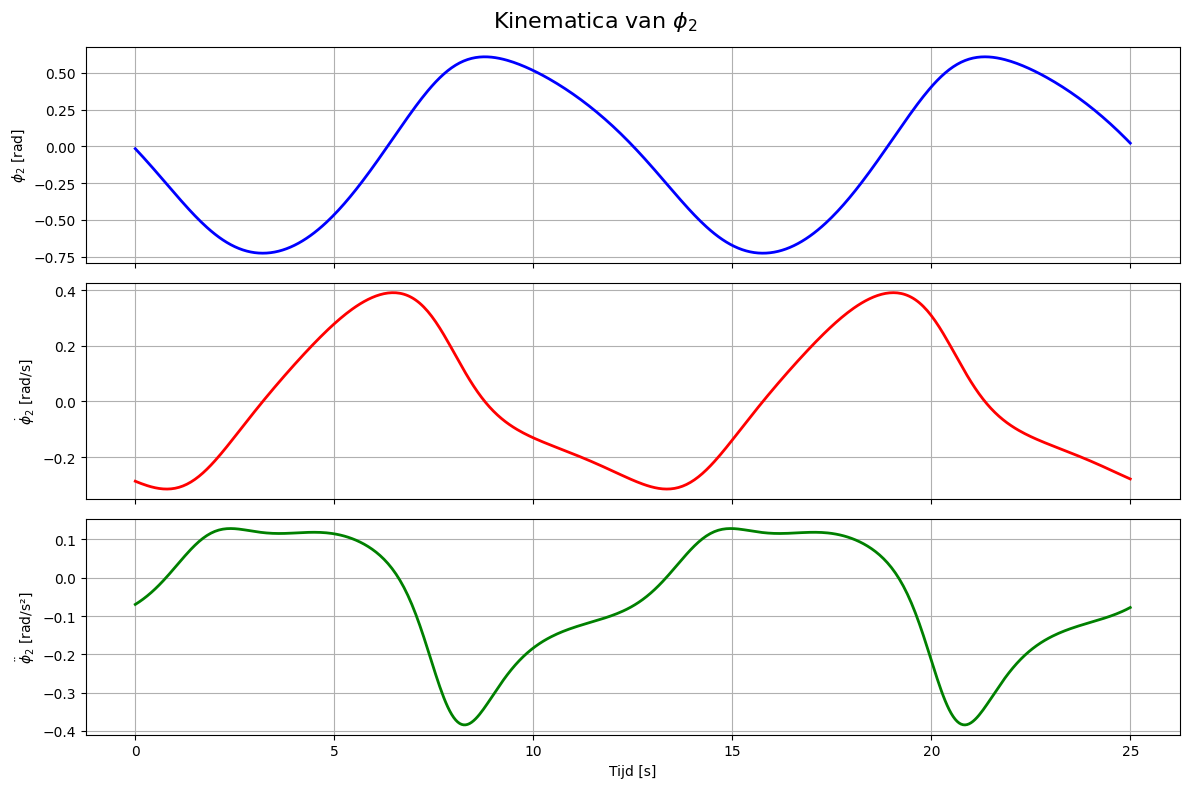

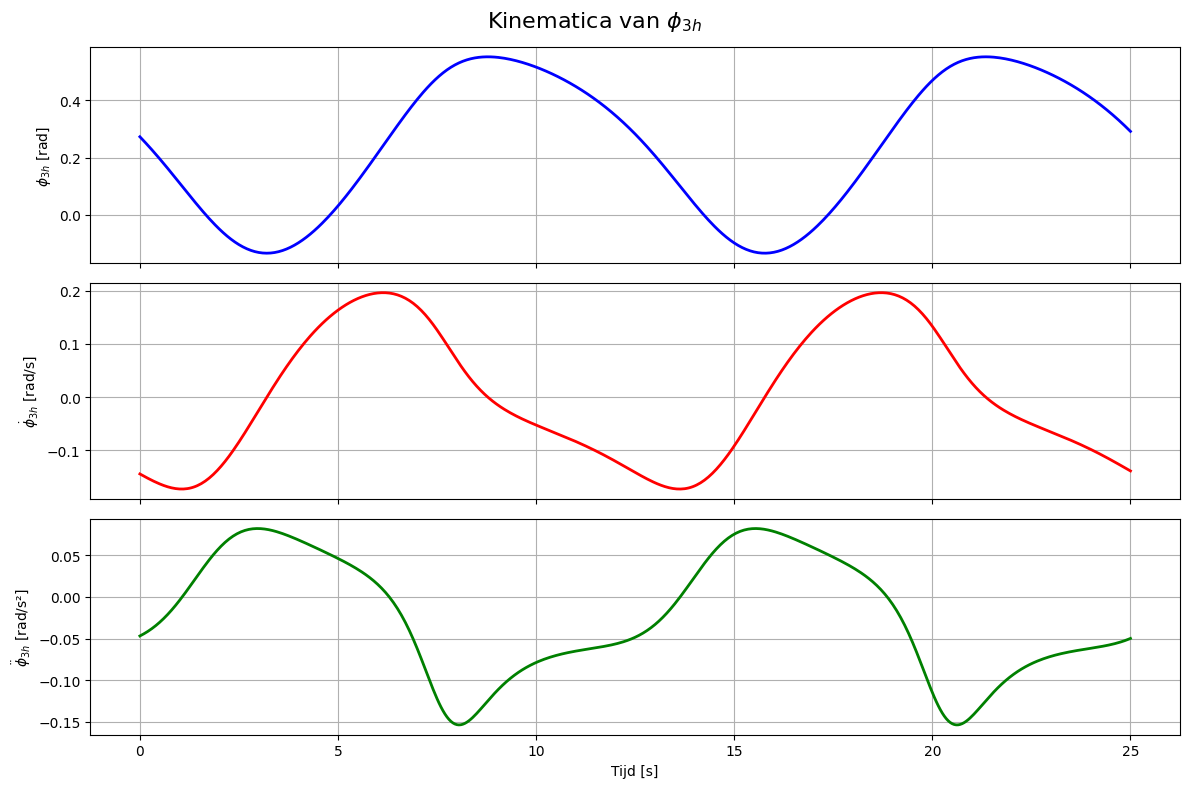

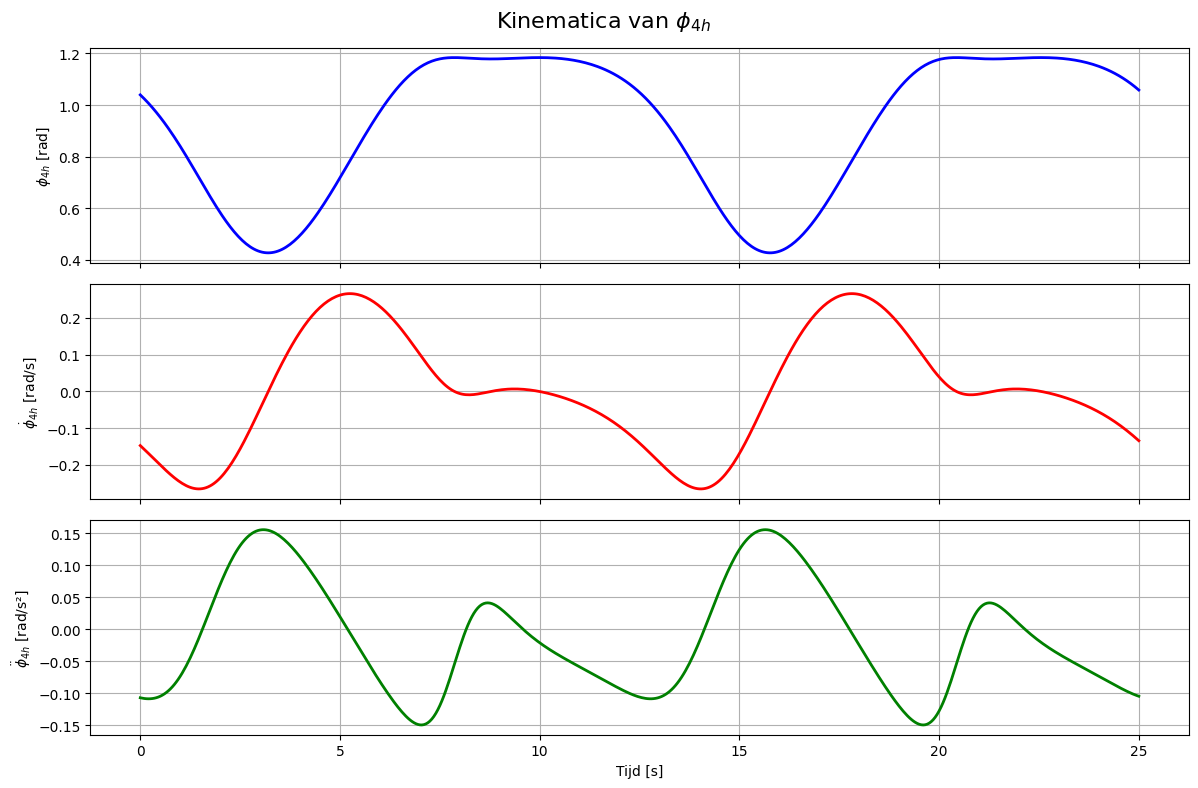

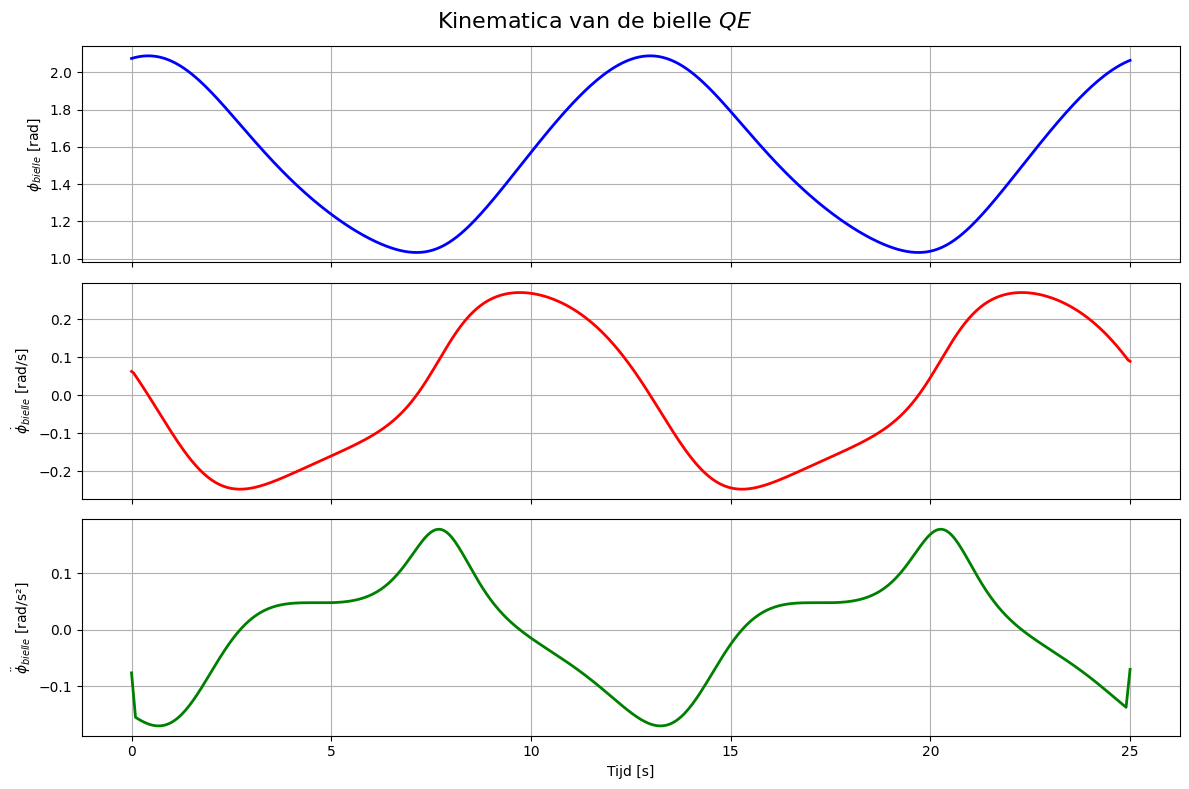

Hauteur maximale de P = 0.13193273414187284 m
Temps associé = 21.35 s
Hauteur minimale de P = -0.15953075575069833 m
Temps associé = 3.2 s


In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

# geometrische parameters

r2  = 0.15
r1  = 0.15
r5l = 0.12
r5h = 0.12
r4l = 0.12
r4h = 0.12

phi2_init  = 0.0
phi4h_init =  math.pi/3
phi4l_init = -math.pi/3

r3l = math.sqrt((r1 + r2*math.cos(phi2_init) + r4l*math.cos(phi4l_init))**2 +
                (      r2*math.sin(phi2_init) + r4l*math.sin(phi4l_init))**2)

r3h = math.sqrt((r1 + r2*math.cos(phi2_init) + r4h*math.cos(phi4h_init))**2 +
                (      r2*math.sin(phi2_init) + r4h*math.sin(phi4h_init))**2)

r3h_ext = r3h

phi3h_init = math.atan2((r2*math.sin(phi2_init) + r4h*math.sin(phi4h_init)),
                        (r1 + r2*math.cos(phi2_init) + r4h*math.cos(phi4h_init)))

phi3l_init = math.atan2((r2*math.sin(phi2_init) + r4l*math.sin(phi4l_init)),
                        (r1 + r2*math.cos(phi2_init) + r4l*math.cos(phi4l_init)))

# Crank-slider
r_crank  = 0.12
L_bielle = 0.25
F = np.array([-0.36, -0.32])

# tijd en driver definitie

t_begin = 0.0
t_end   = 25.0
Ts      = 0.05
t = np.arange(t_begin, t_end + Ts, Ts)

omega_crank = 0.5
theta_crank = omega_crank * t

# Rotatie van vector

def rotate_vector(z, theta):
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    return R @ z


# Sluitingsvergelijkingen

def system_equations(x, theta_k):
    phi2, phi3h, phi4h, phi3l, phi4l = x

    # high lus
    F1 = r1 + r2*np.cos(phi2) + r4h*np.cos(phi4h) - r3h*np.cos(phi3h)
    F2 =      r2*np.sin(phi2) + r4h*np.sin(phi4h) - r3h*np.sin(phi3h)

    # low lus
    F3 = r1 + r2*np.cos(phi2) + r4l*np.cos(phi4l) - r3l*np.cos(phi3l)
    F4 =      r2*np.sin(phi2) + r4l*np.sin(phi4l) - r3l*np.sin(phi3l)

    # Extentie van r3h + crank-slider
    C = np.array([0.0, 0.0])
    E = C + rotate_vector(np.array([r3h_ext, 0.0]), phi3h + np.pi)
    Q = F + rotate_vector(np.array([r_crank, 0.0]), theta_k)

    F5 = (E[0] - Q[0])**2 + (E[1] - Q[1])**2 - L_bielle**2

    return [F1, F2, F3, F4, F5]


# kinematische resolutie

phi2  = np.zeros_like(t)
phi3h = np.zeros_like(t)
phi4h = np.zeros_like(t)
phi3l = np.zeros_like(t)
phi4l = np.zeros_like(t)

dphi2  = np.zeros_like(t)
dphi3h = np.zeros_like(t)
dphi4h = np.zeros_like(t)
dphi3l = np.zeros_like(t)
dphi4l = np.zeros_like(t)

ddphi2  = np.zeros_like(t)
ddphi3h = np.zeros_like(t)
ddphi4h = np.zeros_like(t)
ddphi3l = np.zeros_like(t)
ddphi4l = np.zeros_like(t)

x_guess = np.array([phi2_init, phi3h_init, phi4h_init, phi3l_init, phi4l_init])

for k in range(len(t)):
    
    # ============================
    # Hoeken
    # ============================

    theta_k = theta_crank[k]

    sol = fsolve(lambda x: system_equations(x, theta_k), x_guess)

    phi2[k], phi3h[k], phi4h[k], phi3l[k], phi4l[k] = sol

    x_guess = sol

    phi2_k, phi3h_k, phi4h_k, phi3l_k, phi4l_k = sol

    # ============================
    # Hoeksnelheden
    # ============================

    A = np.zeros((5,5))

    # F1
    A[0,0] = -r2*np.sin(phi2_k)
    A[0,1] =  r3h*np.sin(phi3h_k)
    A[0,2] = -r4h*np.sin(phi4h_k)

    # F2
    A[1,0] =  r2*np.cos(phi2_k)
    A[1,1] = -r3h*np.cos(phi3h_k)
    A[1,2] =  r4h*np.cos(phi4h_k)

    # F3
    A[2,0] = -r2*np.sin(phi2_k)
    A[2,3] =  r3l*np.sin(phi3l_k)
    A[2,4] = -r4l*np.sin(phi4l_k)

    # F4
    A[3,0] =  r2*np.cos(phi2_k)
    A[3,3] = -r3l*np.cos(phi3l_k)
    A[3,4] =  r4l*np.cos(phi4l_k)

    C = np.array([0.0, 0.0])

    E = C + rotate_vector(np.array([r3h_ext, 0.0]), phi3h_k + np.pi)
    Q = F + rotate_vector(np.array([r_crank, 0.0]), theta_k)

    dE_dphi3h = rotate_vector(np.array([r3h_ext, 0.0]), phi3h_k + 3*np.pi/2)

    A[4,1] = 2*(E[0]-Q[0])*dE_dphi3h[0] \
           + 2*(E[1]-Q[1])*dE_dphi3h[1]

    B = np.zeros(5)

    dQ_dtheta = rotate_vector(np.array([r_crank, 0.0]), theta_k + np.pi/2)

    B[4] = 2*(E[0]-Q[0])*dQ_dtheta[0]*omega_crank \
         + 2*(E[1]-Q[1])*dQ_dtheta[1]*omega_crank

    dphi = np.linalg.solve(A, B)

    dphi2[k]  = dphi[0]
    dphi3h[k] = dphi[1]
    dphi4h[k] = dphi[2]
    dphi3l[k] = dphi[3]
    dphi4l[k] = dphi[4]

    # ============================
    # Hoekversnellingen
    # ============================

    dotA = np.zeros((5,5))

    # ligne 1
    dotA[0,0] = -r2*np.cos(phi2_k) * dphi2[k]
    dotA[0,1] =  r3h*np.cos(phi3h_k) * dphi3h[k]
    dotA[0,2] = -r4h*np.cos(phi4h_k) * dphi4h[k]

    # ligne 2
    dotA[1,0] = -r2*np.sin(phi2_k) * dphi2[k]
    dotA[1,1] =  r3h*np.sin(phi3h_k) * dphi3h[k]
    dotA[1,2] = -r4h*np.sin(phi4h_k) * dphi4h[k]

    # ligne 3
    dotA[2,0] = -r2*np.cos(phi2_k) * dphi2[k]
    dotA[2,3] =  r3l*np.cos(phi3l_k) * dphi3l[k]
    dotA[2,4] = -r4l*np.cos(phi4l_k) * dphi4l[k]

    # ligne 4
    dotA[3,0] = -r2*np.sin(phi2_k) * dphi2[k]
    dotA[3,3] =  r3l*np.sin(phi3l_k) * dphi3l[k]
    dotA[3,4] = -r4l*np.sin(phi4l_k) * dphi4l[k]

    # ligne 5
    d2E_dphi3h2 = rotate_vector(np.array([r3h_ext,0]), phi3h_k)

    dotA[4,1] = 2*(dE_dphi3h @ dE_dphi3h)*dphi3h[k] \
              + 2*((E-Q) @ d2E_dphi3h2)*dphi3h[k]

    # 
    # dotB
    # 

    dotB = np.zeros(5)

    d2Q_dtheta2 = -rotate_vector(np.array([r_crank,0]), theta_k)

    dotB[4] = 2*((E-Q) @ d2Q_dtheta2) * omega_crank**2 \
            + 2*(dE_dphi3h @ dQ_dtheta) * dphi3h[k] * omega_crank

    rhs = dotB - dotA @ dphi

    ddphi = np.linalg.solve(A, rhs)

    ddphi2[k]  = ddphi[0]
    ddphi3h[k] = ddphi[1]
    ddphi4h[k] = ddphi[2]
    ddphi3l[k] = ddphi[3]
    ddphi4l[k] = ddphi[4]


# ==========================================================
# ANIMATIE
# ==========================================================

x_left   = -0.55
x_right  =  0.50
y_bottom = -0.50
y_top    =  0.30

C = np.array([0.0, 0.0])

plt.ioff()

fig, ax = plt.subplots()

t_size = len(t)

frames = t_size / 5

delta = int(np.floor(t_size / frames))

index_vec = np.arange(0, t_size, delta, dtype=int)


def update(frame_idx):

    k = index_vec[frame_idx]

    ax.clear()

    ax.set_aspect('equal', adjustable='box')   # Tegen WARNING meldingen

    ax.set_xlabel('[m]')
    ax.set_ylabel('[m]')

    ax.set_xlim(x_left, x_right)
    ax.set_ylim(y_bottom, y_top)

    ax.set_title(f'Frame {k}')

    # Base : C -> A -> B
    A = C + np.array([r1, 0.0])
    B = A + rotate_vector(np.array([r2, 0.0]), phi2[k])

    # High / low branch
    D_h = B + rotate_vector(np.array([r4h, 0.0]), phi4h[k])
    D_l = B + rotate_vector(np.array([r4l, 0.0]), phi4l[k])

    P = D_h + (D_l - B)

    loop_ground  = np.array([C, A, B])
    loop_rhombus = np.array([B, D_h, P, D_l, B])

    loop_r3h = np.array([C, D_h])
    loop_r3l = np.array([C, D_l])

    ax.plot(loop_ground[:,0], loop_ground[:,1], '-o')

    ax.plot(loop_rhombus[:,0], loop_rhombus[:,1], '-o')

    ax.plot(loop_r3h[:,0], loop_r3h[:,1],
            '-o', color='purple', linewidth=2)

    ax.plot(loop_r3l[:,0], loop_r3l[:,1],
            '-o', color='green', linewidth=2)

    # verticale stippellijn
    xP = P[0]

    ax.plot([xP, xP],
            [y_bottom, y_top],
            '--',
            color='lightgray',
            linewidth=1)

    # Extensie
    E = C + rotate_vector(np.array([r3h_ext, 0.0]),
                          phi3h[k] + np.pi)

    ax.plot([C[0], E[0]],
            [C[1], E[1]],
            '-o',
            color='purple',
            linewidth=2)

    # Crank-slider
    Q = F + rotate_vector(np.array([r_crank, 0.0]),
                          theta_crank[k])

    ax.plot([F[0], Q[0]],
            [F[1], Q[1]],
            '-o',
            color='green',
            linewidth=2)

    ax.plot([Q[0], E[0]],
            [Q[1], E[1]],
            '-o',
            color='green',
            linewidth=2)

    return []


ani = FuncAnimation(
    fig,
    update,
    frames=len(index_vec),
    interval=50,
    blit=False
)

plt.close(fig)   # vermijdt parasitaire frames

display(HTML(ani.to_jshtml()))

# ==========================================================
# GRAFIEKEN PHI2
# ==========================================================

fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axs[0].plot(t, phi2, color='blue', linewidth=2)
axs[0].set_ylabel(r'$\phi_2$ [rad]')
axs[0].grid(True)

axs[1].plot(t, dphi2, color='red', linewidth=2)
axs[1].set_ylabel(r'$\dot{\phi}_2$ [rad/s]')
axs[1].grid(True)

axs[2].plot(t, ddphi2, color='green', linewidth=2)
axs[2].set_ylabel(r'$\ddot{\phi}_2$ [rad/s²]')
axs[2].set_xlabel('Tijd [s]')
axs[2].grid(True)

fig.suptitle(r'Kinematica van $\phi_2$', fontsize=16)
plt.tight_layout()
plt.show()

# ==========================================================
# GRAFIEKEN PHI3H
# ==========================================================

fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axs[0].plot(t, phi3h, color='blue', linewidth=2)
axs[0].set_ylabel(r'$\phi_{3h}$ [rad]')
axs[0].grid(True)

axs[1].plot(t, dphi3h, color='red', linewidth=2)
axs[1].set_ylabel(r'$\dot{\phi}_{3h}$ [rad/s]')
axs[1].grid(True)

axs[2].plot(t, ddphi3h, color='green', linewidth=2)
axs[2].set_ylabel(r'$\ddot{\phi}_{3h}$ [rad/s²]')
axs[2].set_xlabel('Tijd [s]')
axs[2].grid(True)

fig.suptitle(r'Kinematica van $\phi_{3h}$', fontsize=16)
plt.tight_layout()
plt.show()

# ==========================================================
# GRAFIEKEN PHI4H
# ==========================================================

fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axs[0].plot(t, phi4h, color='blue', linewidth=2)
axs[0].set_ylabel(r'$\phi_{4h}$ [rad]')
axs[0].grid(True)

axs[1].plot(t, dphi4h, color='red', linewidth=2)
axs[1].set_ylabel(r'$\dot{\phi}_{4h}$ [rad/s]')
axs[1].grid(True)

axs[2].plot(t, ddphi4h, color='green', linewidth=2)
axs[2].set_ylabel(r'$\ddot{\phi}_{4h}$ [rad/s²]')
axs[2].set_xlabel('Tijd [s]')
axs[2].grid(True)

fig.suptitle(r'Kinematica van $\phi_{4h}$', fontsize=16)
plt.tight_layout()
plt.show()

# ==========================================================
# ANGLE DE LA BIELLE QE
# ==========================================================

phi_bielle = np.zeros_like(t)

for k in range(len(t)):

    # point E
    E = C + rotate_vector(
        np.array([r3h_ext, 0.0]),
        phi3h[k] + np.pi
    )

    # point Q
    Q = F + rotate_vector(
        np.array([r_crank, 0.0]),
        theta_crank[k]
    )

    # vecteur QE
    QE = E - Q

    # angle de la bielle
    phi_bielle[k] = np.arctan2(QE[1], QE[0])


# ==========================================================
# VITESSE ET ACCÉLÉRATION ANGULAIRE DE LA BIELLE
# ==========================================================

dphi_bielle = np.gradient(phi_bielle, Ts)
ddphi_bielle = np.gradient(dphi_bielle, Ts)


# ==========================================================
# GRAPHES BIELLE
# ==========================================================

fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axs[0].plot(t, phi_bielle,
            color='blue',
            linewidth=2)

axs[0].set_ylabel(r'$\phi_{bielle}$ [rad]')
axs[0].grid(True)


axs[1].plot(t, dphi_bielle,
            color='red',
            linewidth=2)

axs[1].set_ylabel(r'$\dot{\phi}_{bielle}$ [rad/s]')
axs[1].grid(True)


axs[2].plot(t, ddphi_bielle,
            color='green',
            linewidth=2)

axs[2].set_ylabel(r'$\ddot{\phi}_{bielle}$ [rad/s²]')
axs[2].set_xlabel('Tijd [s]')
axs[2].grid(True)

fig.suptitle(r'Kinematica van de bielle $QE$', fontsize=16)

plt.tight_layout()
plt.show()


# ==========================================================
# HAUTEUR DU POINT P
# ==========================================================

yP = np.zeros_like(t)

for k in range(len(t)):

    # point A
    A = C + np.array([r1, 0.0])

    # point B
    B = A + rotate_vector(
        np.array([r2, 0.0]),
        phi2[k]
    )

    # points Dh et Dl
    Dh = B + rotate_vector(
        np.array([r4h, 0.0]),
        phi4h[k]
    )

    Dl = B + rotate_vector(
        np.array([r4l, 0.0]),
        phi4l[k]
    )

    # point P
    P = Dh + (Dl - B)

    # hauteur
    yP[k] = P[1]

# ==========================================================
# MAX / MIN
# ==========================================================

yP_max = np.max(yP)
yP_min = np.min(yP)

idx_max = np.argmax(yP)
idx_min = np.argmin(yP)

print("Hauteur maximale de P =", yP_max, "m")
print("Temps associé =", t[idx_max], "s")

print("Hauteur minimale de P =", yP_min, "m")
print("Temps associé =", t[idx_min], "s")

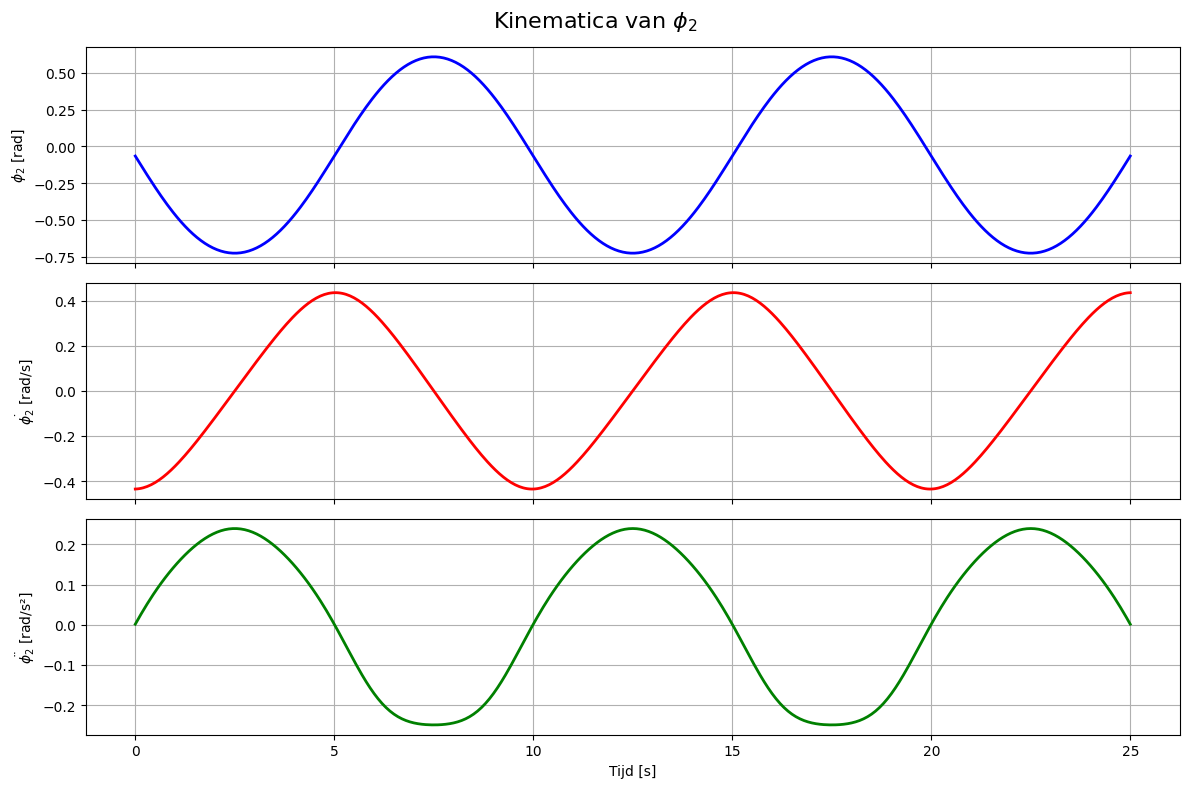

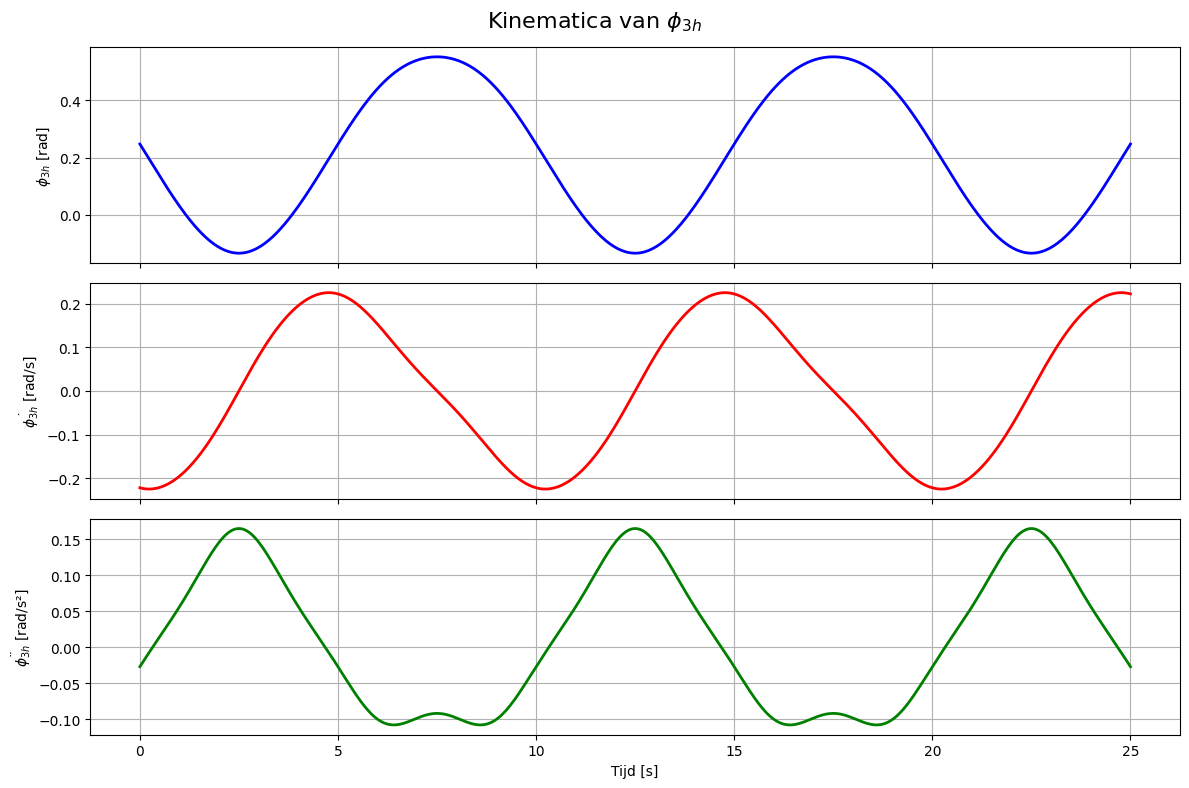

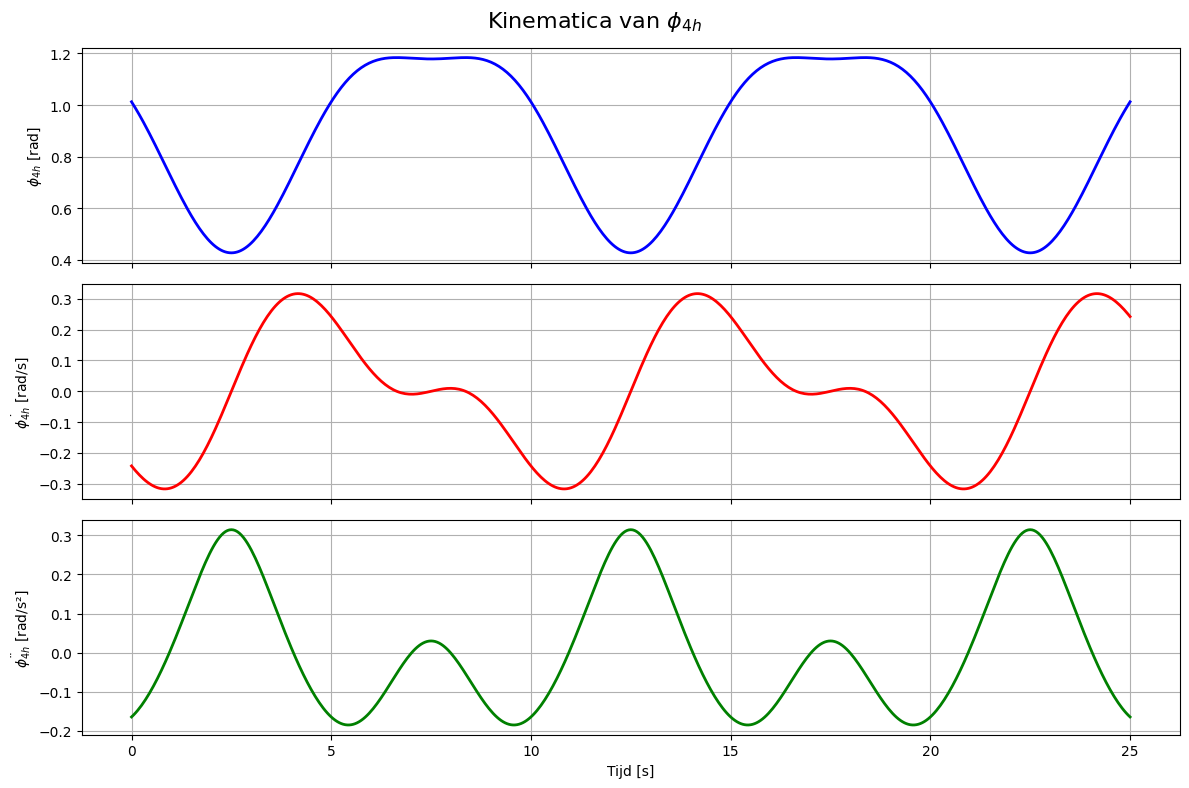

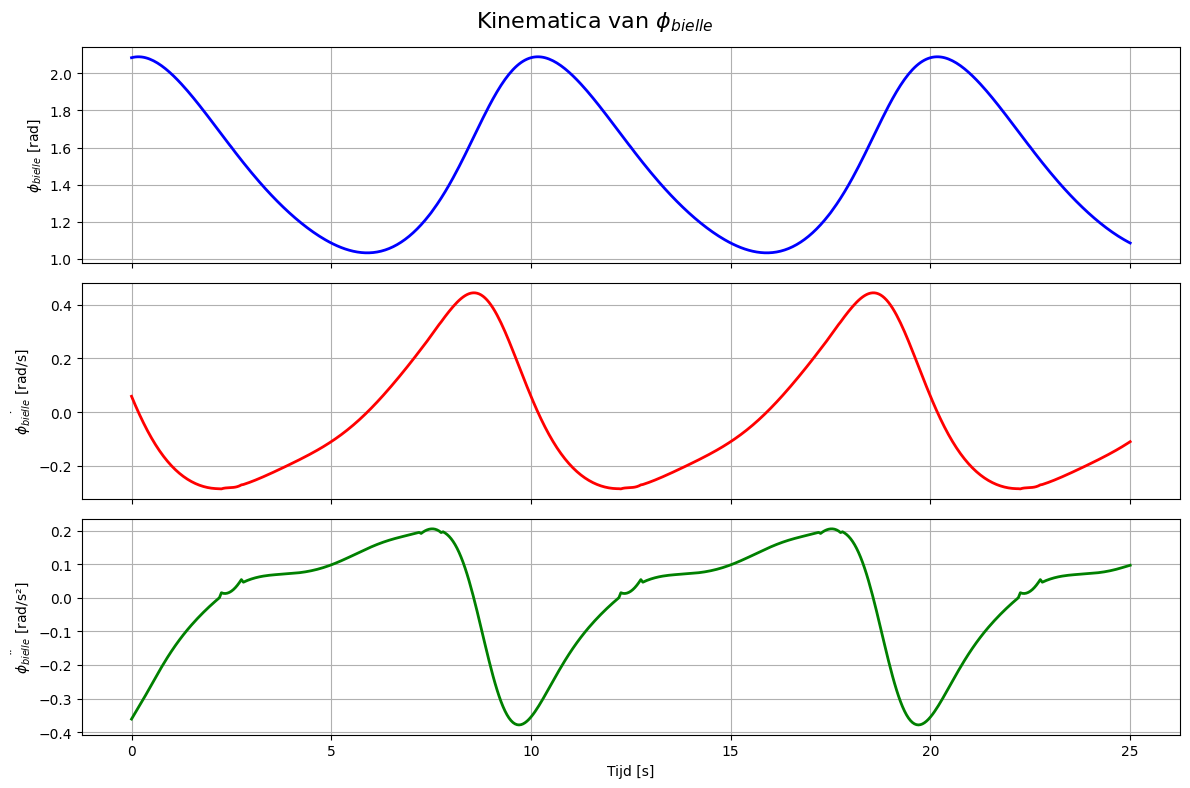

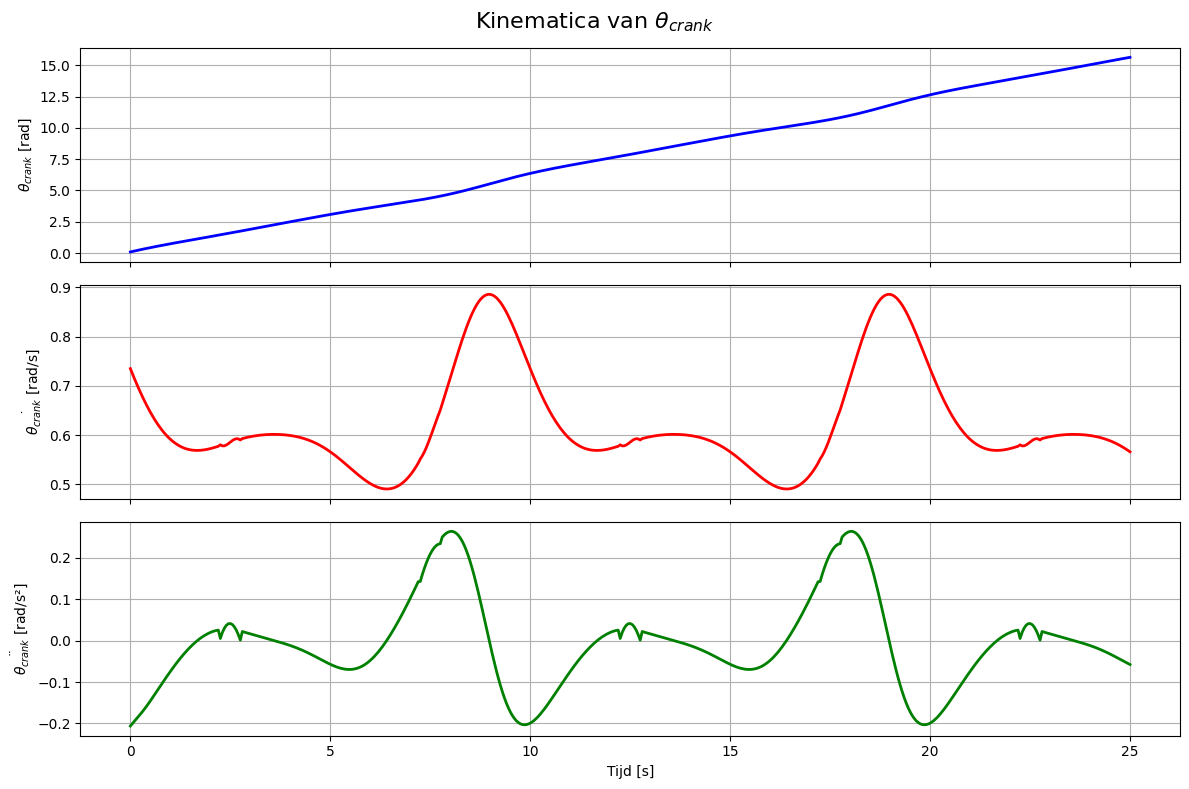

In [3]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

# geometrische parameters

r2  = 0.15 * 2
r1  = 0.15 * 2
r5l = 0.12 * 2
r5h = 0.12 * 2
r4l = 0.12 * 2
r4h = 0.12 * 2

phi2_init  = 0.0
phi4h_init =  math.pi/3
phi4l_init = -math.pi/3

r3l = math.sqrt((r1 + r2*math.cos(phi2_init) + r4l*math.cos(phi4l_init))**2 +
                (      r2*math.sin(phi2_init) + r4l*math.sin(phi4l_init))**2)

r3h = math.sqrt((r1 + r2*math.cos(phi2_init) + r4h*math.cos(phi4h_init))**2 +
                (      r2*math.sin(phi2_init) + r4h*math.sin(phi4h_init))**2)

r3h_ext = r3h

phi3h_init = math.atan2((r2*math.sin(phi2_init) + r4h*math.sin(phi4h_init)),
                        (r1 + r2*math.cos(phi2_init) + r4h*math.cos(phi4h_init)))

phi3l_init = math.atan2((r2*math.sin(phi2_init) + r4l*math.sin(phi4l_init)),
                        (r1 + r2*math.cos(phi2_init) + r4l*math.cos(phi4l_init)))

# Crank-slider
r_crank  = 0.12 * 2
L_bielle = 0.25 * 2
F = np.array([-0.36 * 2, -0.32 * 2])

theta_crank_init = 0


# ==========================================================
# TEMPS
# ==========================================================

t_begin = 0.0
t_end   = 25.0
Ts      = 0.05
t = np.arange(t_begin, t_end + Ts, Ts)

# ==========================================================
# MOUVEMENT IMPOSE DU PISTON P
# ==========================================================

# ==========================================================
# TRAJECTOIRE SINUSOÏDALE ADAPTÉE
# ==========================================================

y_max = 0.13193273414187284 * 2
y_min = -0.15953075575069833 * 2

A = (y_max - y_min)/2
y_mid = (y_max + y_min)/2

f = 0.1   # Hz

P_y = y_mid - A * np.sin(2*np.pi*f*t)

P_x = np.zeros_like(t)

# ==========================================================
# VITESSE / ACCÉLÉRATION IMPOSÉES DU PISTON
# ==========================================================

dP_y = -A*(2*np.pi*f)*np.cos(2*np.pi*f*t)

ddP_y = A*(2*np.pi*f)**2*np.sin(2*np.pi*f*t)
# ==========================================================
# ROTATION HELPER
# ==========================================================

def rotate_vector(z, theta):
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    return R @ z

# point E
C = np.array([0.0, 0.0])
E = C + rotate_vector(
    np.array([r3h_ext, 0.0]),
    phi3h_init + np.pi
)

# point Q
Q = F + rotate_vector(
    np.array([r_crank, 0.0]),
    theta_crank_init
)

# vecteur QE
QE = E - Q

# angle de la bielle
phi_bielle_init = np.arctan2(QE[1], QE[0])

# ==========================================================
# SYSTEME
# ==========================================================

def system_equations(x, P_y_k):
    phi2, phi3h, phi4h, phi3l, phi4l, phi_bielle, theta_crank = x

    # loop haute
    F1 = r1 + r2*np.cos(phi2) + r4h*np.cos(phi4h) - r3h*np.cos(phi3h)
    F2 =      r2*np.sin(phi2) + r4h*np.sin(phi4h) - r3h*np.sin(phi3h)

    # loop basse
    F3 = r1 + r2*np.cos(phi2) + r4l*np.cos(phi4l) - r3l*np.cos(phi3l)
    F4 =      r2*np.sin(phi2) + r4l*np.sin(phi4l) - r3l*np.sin(phi3l)

    F5 = r2*np.sin(phi2) + r4h*np.sin(phi4h) + r5h*np.sin(phi4l) - P_y_k

    # point géométrique E
    C = np.array([0.0, 0.0])
    E = C + rotate_vector(np.array([r3h_ext, 0.0]), phi3h + np.pi)

    # contrainte bielle QE (remplace crank)
    F6 = E[0] - L_bielle*np.cos(phi_bielle) - r_crank*np.cos(theta_crank) - F[0]
    F7 = E[1] - L_bielle*np.sin(phi_bielle) - r_crank*np.sin(theta_crank) - F[1]

    return [F1, F2, F3, F4, F5, F6, F7]

# ==========================================================
# INITIALISATION
# ==========================================================

N = len(t)

phi2  = np.zeros(N)
phi3h = np.zeros(N)
phi4h = np.zeros(N)
phi3l = np.zeros(N)
phi4l = np.zeros(N)
phi_bielle = np.zeros(N)
theta_crank = np.zeros(N)

dphi2  = np.zeros(N)
dphi3h = np.zeros(N)
dphi4h = np.zeros(N)
dphi3l = np.zeros(N)
dphi4l = np.zeros(N)
dphi_bielle = np.zeros(N)
dtheta_crank = np.zeros(N)

ddphi2  = np.zeros(N)
ddphi3h = np.zeros(N)
ddphi4h = np.zeros(N)
ddphi3l = np.zeros(N)
ddphi4l = np.zeros(N)
ddphi_bielle = np.zeros(N)
ddtheta_crank = np.zeros(N)

x_guess = np.array([phi2_init, phi3h_init, phi4h_init, phi3l_init, phi4l_init, phi_bielle_init, theta_crank_init])

# ==========================================================
# LOOP
# ==========================================================

for k in range(N):

    # ======================================================
    # GUESS INITIAL
    # ======================================================

    guess = x_guess.copy()

    # ======================================================
    # RÉSOLUTION
    # ======================================================

    sol = fsolve(
        lambda x: system_equations(x, P_y[k]),
        guess
    )

    phi2_sol, phi3h_sol, phi4h_sol, phi3l_sol, phi4l_sol, phi_bielle_sol, theta_crank_sol = sol

    # ======================================================
    # SI LE CRANK REPART EN ARRIÈRE
    # ======================================================

    if k > 0:

        retry = 0

        while theta_crank_sol < theta_crank[k-1]:

            retry += 1

            # pousse le guess du crank vers l’avant
            guess[6] += 0.05

            # nouvelle résolution
            sol = fsolve(
                lambda x: system_equations(x, P_y[k]),
                guess
            )

            phi2_sol, phi3h_sol, phi4h_sol, \
            phi3l_sol, phi4l_sol, \
            phi_bielle_sol, theta_crank_sol = sol

            # sécurité anti boucle infinie
            if retry > 100:
                print("échec convergence sens rotation")
                break

    # ======================================================
    # STOCKAGE
    # ======================================================

    phi2[k] = phi2_sol
    phi3h[k] = phi3h_sol
    phi4h[k] = phi4h_sol
    phi3l[k] = phi3l_sol
    phi4l[k] = phi4l_sol
    phi_bielle[k] = phi_bielle_sol
    theta_crank[k] = theta_crank_sol

    # ======================================================
    # VARIABLES LOCALES
    # ======================================================

    phi2_k = phi2_sol
    phi3h_k = phi3h_sol
    phi4h_k = phi4h_sol

    phi3l_k = phi3l_sol
    phi4l_k = phi4l_sol

    phi_bielle_k = phi_bielle_sol
    theta_crank_k = theta_crank_sol

    # ======================================================
    # MATRICE JACOBIENNE
    # ======================================================

    J = np.zeros((7,7))

    # ------------------------------------------------------
    # F1
    # ------------------------------------------------------

    J[0,0] = -r2*np.sin(phi2_k)
    J[0,1] =  r3h*np.sin(phi3h_k)
    J[0,2] = -r4h*np.sin(phi4h_k)

    # ------------------------------------------------------
    # F2
    # ------------------------------------------------------

    J[1,0] =  r2*np.cos(phi2_k)
    J[1,1] = -r3h*np.cos(phi3h_k)
    J[1,2] =  r4h*np.cos(phi4h_k)

    # ------------------------------------------------------
    # F3
    # ------------------------------------------------------

    J[2,0] = -r2*np.sin(phi2_k)
    J[2,3] =  r3l*np.sin(phi3l_k)
    J[2,4] = -r4l*np.sin(phi4l_k)

    # ------------------------------------------------------
    # F4
    # ------------------------------------------------------

    J[3,0] =  r2*np.cos(phi2_k)
    J[3,3] = -r3l*np.cos(phi3l_k)
    J[3,4] =  r4l*np.cos(phi4l_k)

    # ------------------------------------------------------
    # F5
    # ------------------------------------------------------

    J[4,0] = r2*np.cos(phi2_k)
    J[4,2] = r4h*np.cos(phi4h_k)
    J[4,4] = r5h*np.cos(phi4l_k)

    # ------------------------------------------------------
    # POINT E
    # ------------------------------------------------------

    E = C + rotate_vector(
        np.array([r3h_ext, 0.0]),
        phi3h_k + np.pi
    )

    # ------------------------------------------------------
    # F6
    # ------------------------------------------------------

    J[5,1] = r3h_ext*np.sin(phi3h_k)

    J[5,5] = L_bielle*np.sin(phi_bielle_k)

    J[5,6] = r_crank*np.sin(theta_crank_k)

    # ------------------------------------------------------
    # F7
    # ------------------------------------------------------

    J[6,1] = -r3h_ext*np.cos(phi3h_k)

    J[6,5] = -L_bielle*np.cos(phi_bielle_k)

    J[6,6] = -r_crank*np.cos(theta_crank_k)

    # ======================================================
    # SECOND MEMBRE VITESSES
    # ======================================================

    rhs_v = np.zeros(7)

    rhs_v[4] = dP_y[k]

    # ======================================================
    # VITESSES ANGULAIRES
    # ======================================================

    dX = np.linalg.solve(J, rhs_v)

    dphi2[k] = dX[0]
    dphi3h[k] = dX[1]
    dphi4h[k] = dX[2]

    dphi3l[k] = dX[3]
    dphi4l[k] = dX[4]

    dphi_bielle[k] = dX[5]
    dtheta_crank[k] = dX[6]

    # ======================================================
    # ACCELERATIONS
    # ======================================================

    rhs_a = np.zeros(7)

    # seule entrée imposée = dérivée seconde du piston
    rhs_a[4] = ddP_y[k]

    Jdot = np.zeros((7,7))

    Jdot[0,0] = -r2*np.cos(phi2_k)*dphi2[k]
    Jdot[0,1] =  r3h*np.cos(phi3h_k)*dphi3h[k]
    Jdot[0,2] = -r4h*np.cos(phi4h_k)*dphi4h[k]

    Jdot[1,0] = -r2*np.sin(phi2_k)*dphi2[k]
    Jdot[1,1] =  r3h*np.sin(phi3h_k)*dphi3h[k]
    Jdot[1,2] = -r4h*np.sin(phi4h_k)*dphi4h[k]

    Jdot[2,0] = -r2*np.cos(phi2_k)*dphi2[k]
    Jdot[2,3] =  r3l*np.cos(phi3l_k)*dphi3l[k]
    Jdot[2,4] = -r4l*np.cos(phi4l_k)*dphi4l[k]

    Jdot[3,0] = -r2*np.sin(phi2_k)*dphi2[k]
    Jdot[3,3] =  r3l*np.sin(phi3l_k)*dphi3l[k]
    Jdot[3,4] = -r4l*np.sin(phi4l_k)*dphi4l[k]

    Jdot[4,0] = -r2*np.sin(phi2_k)*dphi2[k]
    Jdot[4,2] = -r3h*np.sin(phi3h_k)*dphi3h[k]
    Jdot[4,4] = -r5h*np.sin(phi4l_k)*dphi4l[k]

    Jdot[5,1] = r3h_ext*np.cos(phi3h_k)*dphi3h[k]
    Jdot[5,5] = L_bielle*np.cos(phi_bielle_k)*dphi_bielle[k]
    Jdot[5,6] = r_crank*np.cos(theta_crank_k)*dtheta_crank[k]

    Jdot[6,1] = r3h_ext*np.sin(phi3h_k)*dphi3h[k]
    Jdot[6,5] = L_bielle*np.sin(phi_bielle_k)*dphi_bielle[k]
    Jdot[6,6] = r_crank*np.sin(theta_crank_k)*dtheta_crank[k]

    rhs_a = rhs_a - Jdot @ dX
    ddX = np.linalg.solve(J, rhs_a)

    ddphi2[k] = ddX[0]
    ddphi3h[k] = ddX[1]
    ddphi4h[k] = ddX[2]
    ddphi3l[k] = ddX[3]
    ddphi4l[k] = ddX[4]
    ddphi_bielle[k] = ddX[5]
    ddtheta_crank[k] = ddX[6]

    # ======================================================
    # NOUVEAU GUESS
    # ======================================================

    x_guess = np.array([
        phi2_sol,
        phi3h_sol,
        phi4h_sol,
        phi3l_sol,
        phi4l_sol,
        phi_bielle_sol,
        theta_crank_sol
    ])

from scipy.signal import savgol_filter

dphi_bielle = savgol_filter(phi_bielle, 11, 3, deriv=1, delta=Ts)
ddphi_bielle = savgol_filter(phi_bielle, 11, 3, deriv=2, delta=Ts)

dtheta_crank = savgol_filter(theta_crank, 11, 3, deriv=1, delta=Ts)
ddtheta_crank = savgol_filter(theta_crank, 11, 3, deriv=2, delta=Ts)


# ==========================================================
# ANIMATIE
# ==========================================================

x_left   = -0.55 * 2
x_right  =  0.50 * 2
y_bottom = -0.50 * 2
y_top    =  0.30 * 2

C = np.array([0.0, 0.0])

plt.ioff()

fig, ax = plt.subplots()

t_size = len(t)

frames = t_size / 5

delta = int(np.floor(t_size / frames))

index_vec = np.arange(0, t_size, delta, dtype=int)


def update(frame_idx):

    k = index_vec[frame_idx]

    ax.clear()

    ax.set_aspect('equal', adjustable='box')   # Tegen WARNING meldingen

    ax.set_xlabel('[m]')
    ax.set_ylabel('[m]')

    ax.set_xlim(x_left, x_right)
    ax.set_ylim(y_bottom, y_top)

    ax.set_title(f'Frame {k}')

    # Base : C -> A -> B
    A = C + np.array([r1, 0.0])
    B = A + rotate_vector(np.array([r2, 0.0]), phi2[k])

    # High / low branch
    D_h = B + rotate_vector(np.array([r4h, 0.0]), phi4h[k])
    D_l = B + rotate_vector(np.array([r4l, 0.0]), phi4l[k])

    P = D_h + (D_l - B)

    loop_ground  = np.array([C, A, B])
    loop_rhombus = np.array([B, D_h, P, D_l, B])

    loop_r3h = np.array([C, D_h])
    loop_r3l = np.array([C, D_l])

    ax.plot(loop_ground[:,0], loop_ground[:,1], '-o')

    ax.plot(loop_rhombus[:,0], loop_rhombus[:,1], '-o')

    ax.plot(loop_r3h[:,0], loop_r3h[:,1],
            '-o', color='purple', linewidth=2)

    ax.plot(loop_r3l[:,0], loop_r3l[:,1],
            '-o', color='green', linewidth=2)

    # verticale stippellijn
    xP = P[0]

    ax.plot([xP, xP],
            [y_bottom, y_top],
            '--',
            color='lightgray',
            linewidth=1)

    # Extensie
    E = C + rotate_vector(np.array([r3h_ext, 0.0]),
                          phi3h[k] + np.pi)

    ax.plot([C[0], E[0]],
            [C[1], E[1]],
            '-o',
            color='purple',
            linewidth=2)

    # Crank-slider
    Q = F + rotate_vector(np.array([r_crank, 0.0]),
                          theta_crank[k])

    ax.plot([F[0], Q[0]],
            [F[1], Q[1]],
            '-o',
            color='green',
            linewidth=2)

    ax.plot([Q[0], E[0]],
            [Q[1], E[1]],
            '-o',
            color='green',
            linewidth=2)

    return []


ani = FuncAnimation(
    fig,
    update,
    frames=len(index_vec),
    interval=50,
    blit=False
)

plt.close(fig)   # vermijdt parasitaire frames

display(HTML(ani.to_jshtml()))

# ==========================================================
# PLOTS KINEMATIQUES (comme ancien code)
# ==========================================================

def plot_kinematics(t, phi, dphi, ddphi, name):
    fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

    axs[0].plot(t, phi, color='blue', linewidth=2)
    axs[0].set_ylabel(fr'${name}$ [rad]')
    axs[0].grid(True)

    axs[1].plot(t, dphi, color='red', linewidth=2)
    axs[1].set_ylabel(fr'$\dot{{{name}}}$ [rad/s]')
    axs[1].grid(True)

    axs[2].plot(t, ddphi, color='green', linewidth=2)
    axs[2].set_ylabel(fr'$\ddot{{{name}}}$ [rad/s²]')
    axs[2].set_xlabel('Tijd [s]')
    axs[2].grid(True)

    fig.suptitle(fr'Kinematica van ${name}$', fontsize=16)
    plt.tight_layout()
    plt.show()


# ==========================================================
# φ2
# ==========================================================
plot_kinematics(t, phi2, dphi2, ddphi2, r'\phi_2')

# ==========================================================
# φ3h
# ==========================================================
plot_kinematics(t, phi3h, dphi3h, ddphi3h, r'\phi_{3h}')

# ==========================================================
# φ4h
# ==========================================================
plot_kinematics(t, phi4h, dphi4h, ddphi4h, r'\phi_{4h}')

# ==========================================================
# φ_bielle
# ==========================================================
plot_kinematics(t, phi_bielle, dphi_bielle, ddphi_bielle, r'\phi_{bielle}')

# ==========================================================
# θ_crank
# ==========================================================
plot_kinematics(t, theta_crank, dtheta_crank, ddtheta_crank, r'\theta_{crank}')




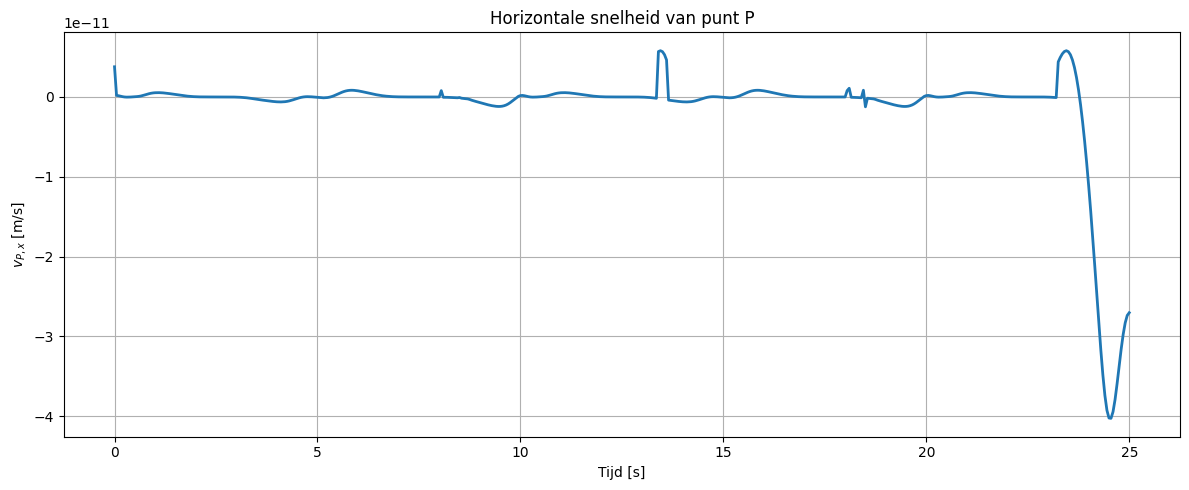

In [4]:
# ==========================================================
# DYNAMIQUE DU MÉCANISME
# ==========================================================

# ----------------------------------------------------------
# OUTILS CINÉMATIQUES
# ----------------------------------------------------------

def next_joint_vel(vA, r, phi, dphi):

    vx = vA[0] - r*np.sin(phi)*dphi
    vy = vA[1] + r*np.cos(phi)*dphi

    return np.array([vx, vy])


def next_joint_acc(aA, r, phi, dphi, ddphi):

    ax = aA[0] - r*np.cos(phi)*dphi**2 - r*np.sin(phi)*ddphi
    ay = aA[1] - r*np.sin(phi)*dphi**2 + r*np.cos(phi)*ddphi

    return np.array([ax, ay])


def cog_kinematics(valA, valB, Cog_parameter):

    return valA * (1 - Cog_parameter) + valB * Cog_parameter


# ----------------------------------------------------------
# CLASSE BARRE
# ----------------------------------------------------------

class BarLink:
    def __init__(self, density, diameter, length, vBegin, vEnd, aBegin, aEnd, Cog_parameter, intern_joint_position=None, angular_velocity=None, angular_acceleration=None):
        self.density = density    # kg/m^3
        self.diameter = diameter  # meters
        self.length = length      # meters
        self.angular_velocity = angular_velocity  # rad/s (optional), used when considering the moment of inertia and rotational dynamics
        self.angular_acceleration = angular_acceleration  # rad/s^2 (optional), used when considering the moment of inertia and rotational dynamics
        self.Cog_parameter = Cog_parameter  # CoG position as a fraction of the link length
        self.intern_joint_position = intern_joint_position  # Internal joint position as a distance from the beginning of the link

        # kinematics of the CoM (considering CoM at the middle of the link)
        self.velocity = cog_kinematics(vBegin, vEnd, self.Cog_parameter)
        self.acceleration = cog_kinematics(aBegin, aEnd, self.Cog_parameter)

    @property
    def cross_sectional_area(self):
        """Calculates area: A = π * r²"""
        radius = self.diameter / 2
        return np.pi * (radius**2)

    @property
    def volume(self):
        """Calculates volume: V = Area * Length"""
        return self.cross_sectional_area * self.length

    @property
    def mass(self):
        """Calculates mass: m = Density * Volume"""
        return self.density * self.volume
    @property
    def distance_Cog_intern_joint(self):
        """Calculates distance from CoG to internal joint, if positive => positive moment (on the right of the CoG)"""
        return self.intern_joint_position - self.Cog_parameter * self.length
    
    def distance_Cog_joint(self, joint_number):
        """Calculates distance from CoG to joint, if positive => positive moment (on the right of the CoG)"""
        if joint_number == 1:
            return self.Cog_parameter * self.length
        elif joint_number == 2:
            return self.length - self.Cog_parameter * self.length
    @property
    def inertia(self):
        """Calculates moment of inertia about the CoG for a rod rotating about its center: I = (1/12) * m * L²"""
        return (1/12) * self.mass * self.length**2


# ==========================================================
# CINÉMATIQUE DES POINTS
# ==========================================================

N = len(t)

# point fixe
vC = np.zeros((2, N))
aC = np.zeros((2, N))

# point A
vA = np.zeros((2, N))
aA = np.zeros((2, N))

# point B
vB = next_joint_vel(vA, r2, phi2, dphi2)
aB = next_joint_acc(aA, r2, phi2, dphi2, ddphi2)

# branche haute : D_h
vDh = next_joint_vel(vB, r4h, phi4h, dphi4h)
aDh = next_joint_acc(aB, r4h, phi4h, dphi4h, ddphi4h)

# branche basse : D_l
vDl = next_joint_vel(vB, r4l, phi4l, dphi4l)
aDl = next_joint_acc(aB, r4l, phi4l, dphi4l, ddphi4l)

# punt P
# géométrie :
# P = D_h + (D_l - B)

P_x = np.zeros(N)
P_y = np.zeros(N)

vP = np.zeros((2, N))
aP = np.zeros((2, N))

for k in range(N):

    # coordinaten van de punten
    Bk = np.array([
        r1 + r2*np.cos(phi2[k]),
        r2*np.sin(phi2[k])
    ])

    Dhk = np.array([
        r3h*np.cos(phi3h[k]),
        r3h*np.sin(phi3h[k])
    ])

    Dlk = np.array([
        r3l*np.cos(phi3l[k]),
        r3l*np.sin(phi3l[k])
    ])

    # point P du parallélogramme
    Pk = Dhk + (Dlk - Bk)

    P_x[k] = Pk[0]
    P_y[k] = Pk[1]

    # vitesse :
    # vP = vDh + (vDl - vB)

    vP[:,k] = vDh[:,k] + (vDl[:,k] - vB[:,k])

    # accélération
    aP[:,k] = aDh[:,k] + (aDl[:,k] - aB[:,k])

# =============================================================
# Check: plot horizontale snelheid van punt P => Moet nul zijn
# =============================================================

plt.figure(figsize=(12,5))

plt.plot(t, vP[0], linewidth=2)

plt.xlabel('Tijd [s]')
plt.ylabel(r'$v_{P,x}$ [m/s]')

plt.title('Horizontale snelheid van punt P')

plt.grid(True)

plt.tight_layout()

plt.show()

# ==============================================================

# extension E
vE = next_joint_vel(vC, r3h_ext, phi3h + np.pi, dphi3h)
aE = next_joint_acc(aC, r3h_ext, phi3h + np.pi, dphi3h, ddphi3h)

# crank point Q
vQ = np.array([
    -r_crank*np.sin(theta_crank)*omega_crank,
     r_crank*np.cos(theta_crank)*omega_crank
])

aQ = np.array([
    -r_crank*np.cos(theta_crank)*omega_crank**2,
    -r_crank*np.sin(theta_crank)*omega_crank**2
])

# Fixed point F
vF_fixed = np.zeros((2, N))
aF_fixed = np.zeros((2, N))

# ==========================================================
# PROPRIÉTÉS MATÉRIAU
# ==========================================================

densityAL = 2700
diameter = 0.01
g = 9.81

Cog_parameter = 0.5

# ==========================================================
# BARRES
# ==========================================================

bar_AB = BarLink(
    density=densityAL,
    diameter=diameter,
    length=r2,
    vBegin=vA,
    vEnd=vB,
    aBegin=aA,
    aEnd=aB,
    Cog_parameter=Cog_parameter,
    angular_velocity=dphi2,
    angular_acceleration=ddphi2
)

bar_BDh = BarLink(
    density=densityAL,
    diameter=diameter,
    length=r4h,
    vBegin=vB,
    vEnd=vDh,
    aBegin=aB,
    aEnd=aDh,
    Cog_parameter=Cog_parameter,
    angular_velocity=dphi4h,
    angular_acceleration=ddphi4h
)

bar_CDl = BarLink(
    density=densityAL,
    diameter=diameter,
    length=r3l,
    vBegin=vC,
    vEnd=vDl,
    aBegin=aC,
    aEnd=aDl,
    Cog_parameter=Cog_parameter,
    angular_velocity=dphi3l,
    angular_acceleration=ddphi3l
)

bar_BDl = BarLink(
    density=densityAL,
    diameter=diameter,
    length=r4l,
    vBegin=vB,
    vEnd=vDl,
    aBegin=aB,
    aEnd=aDl,
    Cog_parameter=Cog_parameter,
    angular_velocity=dphi4l,
    angular_acceleration=ddphi4l
)

bar_DhP = BarLink(
    density=densityAL,
    diameter=diameter,
    length=r4l,
    vBegin=vDh,
    vEnd=vP,
    aBegin=aDh,
    aEnd=aP,
    Cog_parameter=Cog_parameter,
    angular_velocity=dphi4l,
    angular_acceleration=ddphi4l
)

bar_DlP = BarLink(
    density=densityAL,
    diameter=diameter,
    length=r4h,
    vBegin=vDl,
    vEnd=vP,
    aBegin=aDl,
    aEnd=aP,
    Cog_parameter=Cog_parameter,
    angular_velocity=dphi4h,
    angular_acceleration=ddphi4h
)

bar_EDh = BarLink(
    density=densityAL,
    diameter=diameter,
    length=r3h + r3h_ext,
    intern_joint_position=r3h_ext,
    vBegin=vE,
    vEnd=vDh,
    aBegin=aE,
    aEnd=aDh,
    Cog_parameter=Cog_parameter,
    angular_velocity=dphi3h,
    angular_acceleration=ddphi3h
)

bar_QE = BarLink(
    density=densityAL,
    diameter=diameter,
    length=L_bielle,
    vBegin=vQ,
    vEnd=vE,
    aBegin=aQ,
    aEnd=aE,
    Cog_parameter=Cog_parameter,
    angular_velocity=dphi_bielle,
    angular_acceleration=ddphi_bielle
)

bar_FQ = BarLink(
    density=densityAL,
    diameter=diameter,
    length=r_crank,
    vBegin=vF_fixed,
    vEnd=vQ,
    aBegin=aF_fixed,
    aEnd=aQ,
    Cog_parameter=Cog_parameter,
    angular_velocity=np.ones(N)*omega_crank,
    angular_acceleration=np.zeros(N)
)


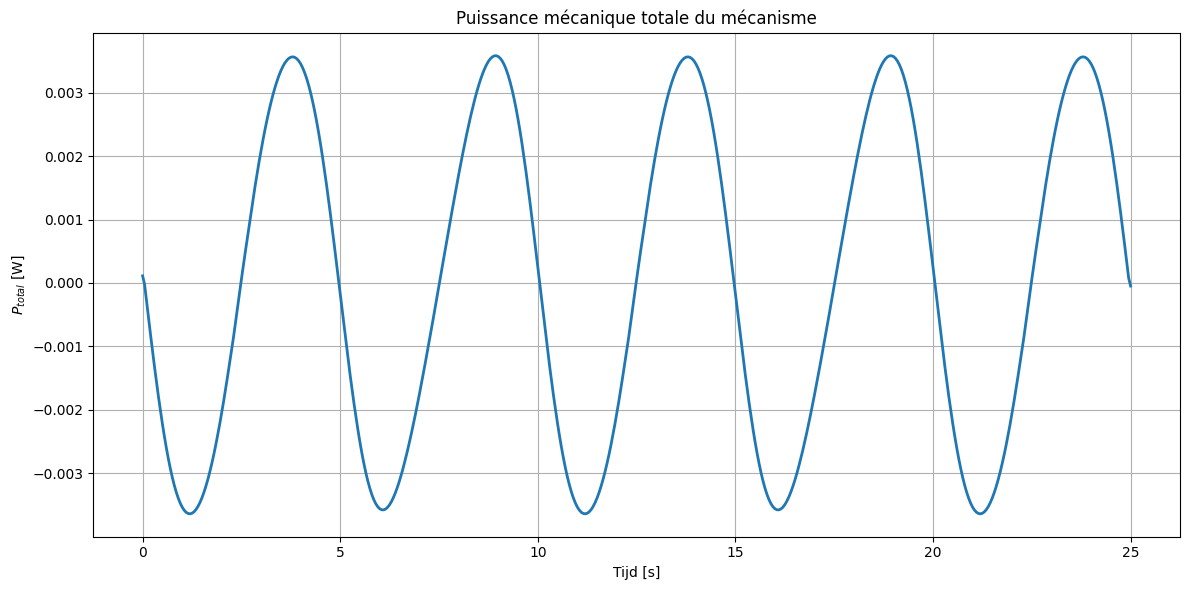

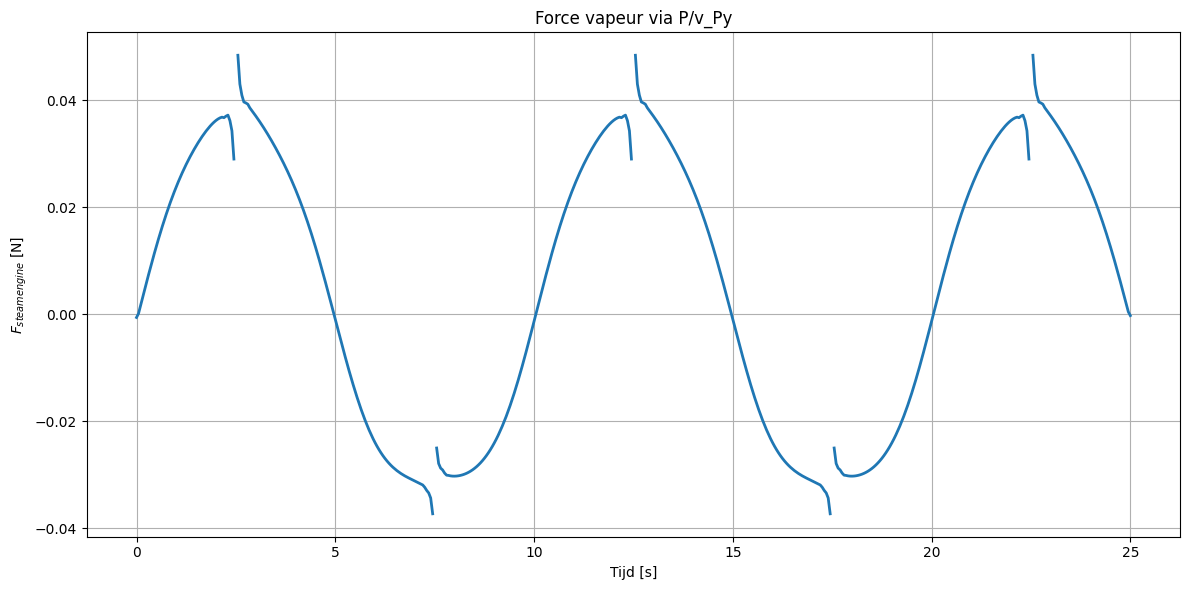

In [5]:

# ==========================================================
# ÉNERGIE CINÉTIQUE TOTALE
# ==========================================================

def kinetic_energy(bar):

    # norme² de la vitesse du CoG
    v2 = np.sum(bar.velocity**2, axis=0)

    # énergie translation
    E_trans = 0.5 * bar.mass * v2

    # énergie rotation
    E_rot = 0.5 * bar.inertia * bar.angular_velocity**2

    return E_trans + E_rot


# ==========================================================
# ÉNERGIE TOTALE DU SYSTÈME
# ==========================================================

E_total = (
    kinetic_energy(bar_AB)
    + kinetic_energy(bar_BDh)
    + kinetic_energy(bar_CDl)
    + kinetic_energy(bar_BDl)
    + kinetic_energy(bar_DhP)
    + kinetic_energy(bar_DlP)
    + kinetic_energy(bar_EDh)
    + kinetic_energy(bar_QE)
    + kinetic_energy(bar_FQ)
)


# ==========================================================
# PUISSANCE = dE/dt
# ==========================================================

# gradient robuste
P_total = np.gradient(E_total, t)

# ==========================================================
# PLOT : PUISSANCE TOTALE
# ==========================================================

plt.figure(figsize=(12,6))

plt.plot(t, P_total, linewidth=2)

plt.xlabel('Tijd [s]')
plt.ylabel(r'$P_{total}$ [W]')

plt.title('Puissance mécanique totale du mécanisme')

plt.grid(True)

plt.tight_layout()
plt.show()

# ==========================================================
# FORCE ÉQUIVALENTE AU PISTON
# ==========================================================

# éviter les divisions instables
vPy = vP[1].copy()

# sécurité numérique (points morts)
eps = 1e-4
vPy_safe = np.where(np.abs(vPy) < eps, np.nan, vPy)

F_steamengine = P_total / vPy_safe

plt.figure(figsize=(12,6))

plt.plot(t, F_steamengine, linewidth=2)

plt.xlabel('Tijd [s]')
plt.ylabel(r'$F_{steamengine}$ [N]')
plt.title('Force vapeur via P/v_Py')

plt.grid(True)
plt.tight_layout()
plt.show()


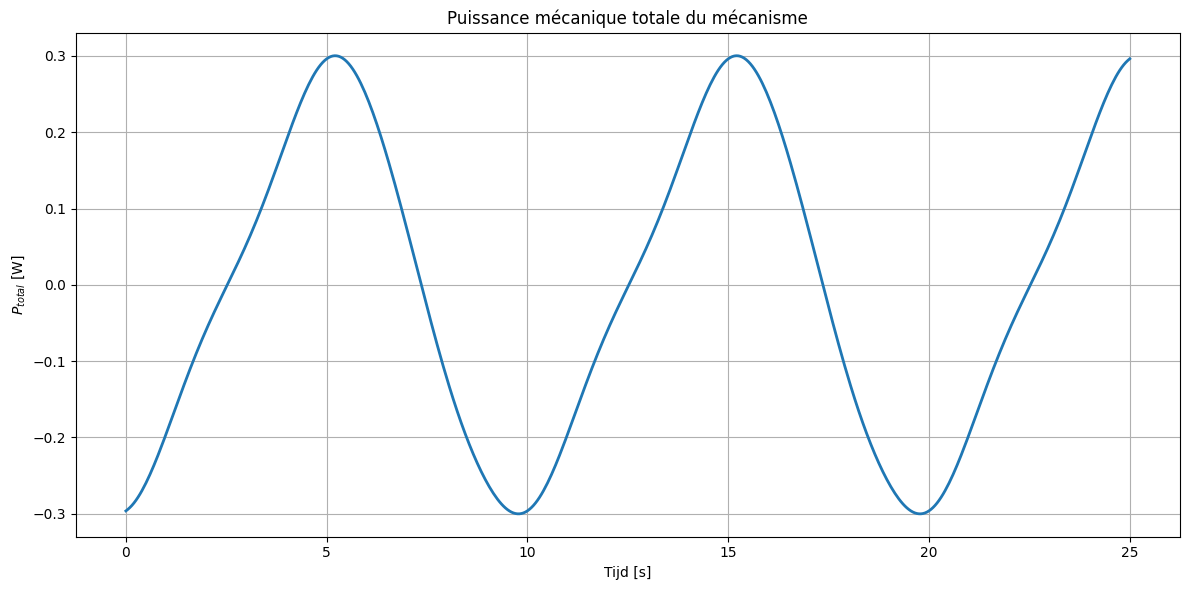

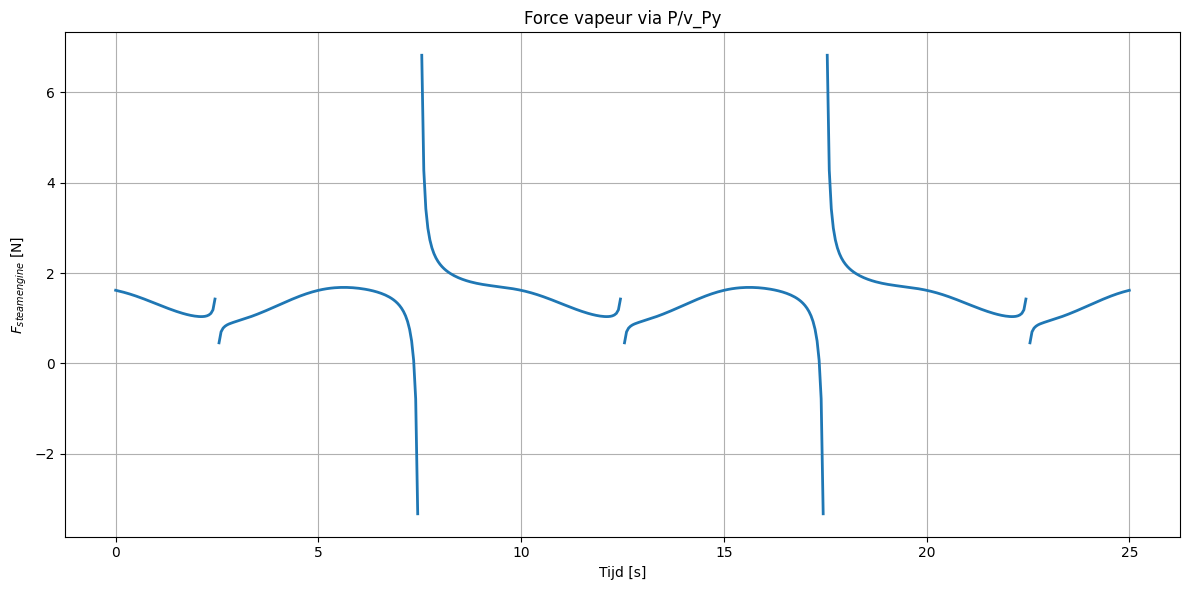

In [8]:

P_kin = np.gradient(E_total, t)

P_grav = (
    bar_AB.mass * g * bar_AB.velocity[1]
    + bar_BDh.mass * g * bar_BDh.velocity[1]
    + bar_CDl.mass * g * bar_CDl.velocity[1]
    + bar_BDl.mass * g * bar_BDl.velocity[1]
    + bar_DhP.mass * g * bar_DhP.velocity[1]
    + bar_DlP.mass * g * bar_DlP.velocity[1]
    + bar_EDh.mass * g * bar_EDh.velocity[1]
    + bar_QE.mass * g * bar_QE.velocity[1]
    + bar_FQ.mass * g * bar_FQ.velocity[1]
)

P_total = P_kin + P_grav
# ==========================================================
# PLOT : PUISSANCE TOTALE
# ==========================================================

plt.figure(figsize=(12,6))

plt.plot(t, P_total, linewidth=2)

plt.xlabel('Tijd [s]')
plt.ylabel(r'$P_{total}$ [W]')

plt.title('Puissance mécanique totale du mécanisme')

plt.grid(True)

plt.tight_layout()
plt.show()

# ==========================================================
# FORCE ÉQUIVALENTE AU PISTON
# ==========================================================

# éviter les divisions instables
vPy = vP[1].copy()

# sécurité numérique (points morts)
eps = 1e-4
vPy_safe = np.where(np.abs(vPy) < eps, np.nan, vPy)

F_steamengine = P_total / vPy_safe

plt.figure(figsize=(12,6))

plt.plot(t, F_steamengine, linewidth=2)

plt.xlabel('Tijd [s]')
plt.ylabel(r'$F_{steamengine}$ [N]')
plt.title('Force vapeur via P/v_Py')

plt.grid(True)
plt.tight_layout()
plt.show()
